In [ ]:
! pip install https://github.com/state-spaces/mamba/releases/download/v2.2.5/mamba_ssm-2.2.5+cu12torch2.8cxx11abiFALSE-cp312-cp312-linux_x86_64.whl

In [1]:
! nvidia-smi

Wed Jan 28 10:49:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:41:00.0 Off |                  Off |
|  0%   37C    P8             25W /  450W |    3915MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.
You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.


Number of MambaByte test samples: 19
MambaByte PG19 Parameters: 373,950,464
MambaByte PG19 Approximate Size: 0.374B


Evaluating MambaByte PG19 Samples: 100%|██████████| 19/19 [00:01<00:00, 11.33it/s]
You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.
You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.


...

Number of PMNet test samples: 19


You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.


PMNet Parameters : 118,970,368
PMNet Approximate Size: 0.119B


Evaluating PMNet Samples: 100%|██████████| 19/19 [00:01<00:00, 10.43it/s]


Graph saved to data/long_context_bpb_comparison.pdf


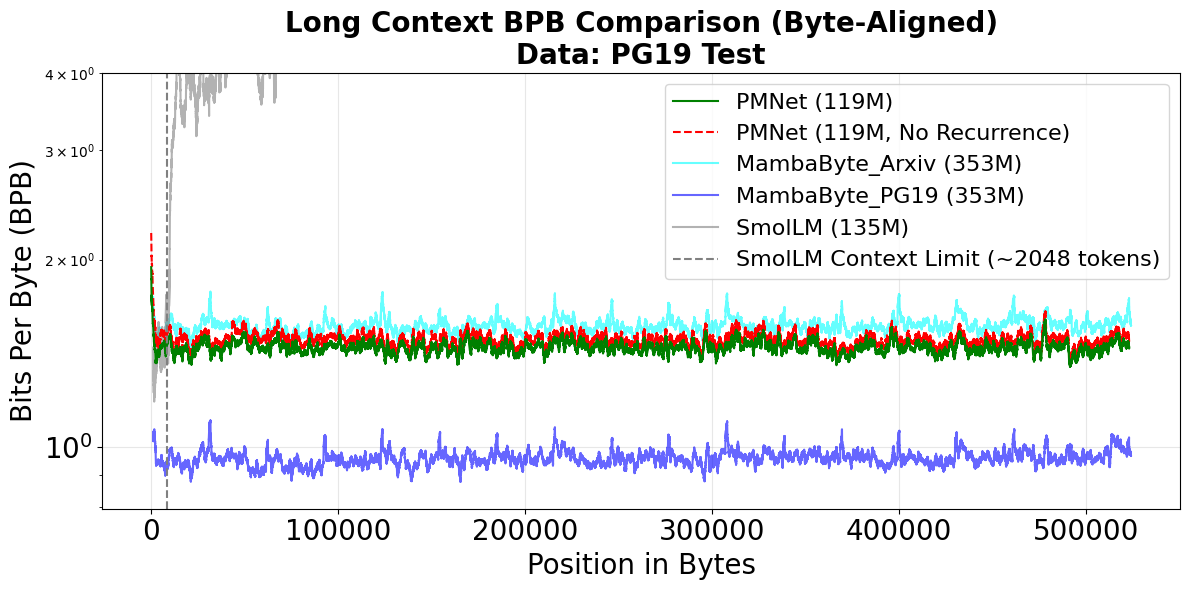

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from tqdm import tqdm
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel

try:
	from mamba_ssm.utils.generation import InferenceParams
except Exception:
	InferenceParams = None

DATASET_ID = "emozilla/pg19"
DATA_SPLIT = "test"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MambaByteCKPT_PATH = "JunxiongWang/MambaByte_PG19_353M"
MambaByteArxivCKPT_PATH = "JunxiongWang/MambaByte_Arxiv"
PMNet_MODEL_ID = "pmnet-icml2026-10724/pmnet"
DATA_PROCESS_BATCH_SIZE = 1000
NUM_PROC = 16
SEQ_LENGTH_MAMBA = 512 * 1024
NUM_EVAL_SAMPLES = 19
MAMBA_LOSS_DIR = "data/mambabyte_losses_512k"
os.makedirs(MAMBA_LOSS_DIR, exist_ok=True)

SMOL_CKPT_PATH = "HuggingFaceTB/SmolLM-135M"
SEQ_LENGTH_SMOL = 16384
CHUNK_SIZE_SMOL = 512

PMNET_CKPT_PATH = "pmnet-icml2026-10724/pmnet"
SEQ_LENGTH_PMNET = 512 * 1024
PMNET_NUM_EVAL_SAMPLES = 19
PMNET_LOSS_DIR = "data/byte_losses_pg19_512k"
os.makedirs(PMNET_LOSS_DIR, exist_ok=True)


def _extract_logits(outputs):
	if hasattr(outputs, "logits"):
		return outputs.logits
	if isinstance(outputs, (tuple, list)) and len(outputs) > 0:
		return outputs[0]
	return outputs


def _byte_lengths_for_tokens(tokenizer, input_ids):
	decoded_tokens = [len(tokenizer.decode([t]).encode("utf-8")) for t in input_ids]
	return decoded_tokens


def _byte_indices_from_lengths(byte_lengths):
	byte_indices = []
	current = 0
	for b in byte_lengths:
		current += b
		byte_indices.append(current)
	return byte_indices


def get_loss_over_positions(model, input_ids, ablation=False, chunk_size=1024 * 30):
	if ablation:
		raise NotImplementedError(
			"MambaByte ablation is not implemented in this script."
		)

	model.eval()
	seq_len = len(input_ids)
	all_losses = []
	criterion = nn.CrossEntropyLoss(reduction="none")

	with torch.no_grad():
		for i in range(0, seq_len, chunk_size):
			end_idx = min(i + chunk_size, seq_len)
			chunk_input = input_ids[i:end_idx]

			label_end_idx = min(i + chunk_size + 1, seq_len)
			chunk_labels_ids = input_ids[i + 1 : label_end_idx]

			input_tensor = torch.tensor(
				chunk_input,
				dtype=torch.long,
				device="cuda" if torch.cuda.is_available() else "cpu",
			).unsqueeze(0)

			outputs = model(input_ids=input_tensor)
			logits = _extract_logits(outputs)

			if len(chunk_labels_ids) == len(chunk_input):
				shift_logits = logits.contiguous()
				shift_labels = torch.tensor(
					chunk_labels_ids,
					dtype=torch.long,
					device="cuda" if torch.cuda.is_available() else "cpu",
				)
			else:
				shift_logits = logits[..., :-1, :].contiguous()
				shift_labels = input_tensor[..., 1:].contiguous()

			loss = criterion(
				shift_logits.view(-1, shift_logits.size(-1)),
				shift_labels.view(-1),
			)
			all_losses.extend(loss.detach().float().cpu().numpy().tolist())

			del outputs, logits
			if torch.cuda.is_available():
				torch.cuda.empty_cache()

	return all_losses


def get_loss_over_positions_pmnet(model, input_ids, ablation=False, chunk_size=1024 * 30):
	model.eval()
	device_local = model.device
	seq_len = len(input_ids)
	all_losses = []

	past_key_values = None

	original_cumsum_config = model.config.memory_cumsum
	if ablation:
		model.config.memory_cumsum = False

	criterion = nn.CrossEntropyLoss(reduction="none")

	with torch.no_grad():
		for i in range(0, seq_len, chunk_size):
			end_idx = min(i + chunk_size, seq_len)
			chunk_input = input_ids[i:end_idx]

			label_end_idx = min(i + chunk_size + 1, seq_len)
			chunk_labels_ids = input_ids[i + 1 : label_end_idx]

			input_tensor = (
				torch.tensor(chunk_input, dtype=torch.long).unsqueeze(0).to(device_local)
			)

			outputs = model(
				input_ids=input_tensor,
				past_key_values=past_key_values,
				use_cache=True,
			)

			past_key_values = outputs.past_key_values

			if ablation and past_key_values is not None:
				if hasattr(past_key_values, "_memory_states_storage"):
					for block_idx in past_key_values._memory_states_storage:
						past_key_values._memory_states_storage[block_idx].zero_()

			logits = outputs.logits

			if len(chunk_labels_ids) == len(chunk_input):
				shift_logits = logits.contiguous()
				shift_labels = torch.tensor(chunk_labels_ids, dtype=torch.long).to(
					device_local
				)
			else:
				shift_logits = logits[..., :-1, :].contiguous()
				shift_labels = input_tensor[..., 1:].contiguous()

			loss = criterion(
				shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1)
			)
			all_losses.extend(loss.cpu().numpy().tolist())

			del outputs
			del logits
			if torch.cuda.is_available():
				torch.cuda.empty_cache()

	model.config.memory_cumsum = original_cumsum_config

	return all_losses


def prepare_mamba_dataset(tokenizer):
	test_dataset = load_dataset(DATASET_ID, split=DATA_SPLIT)

	def process_batch(examples):
		tokenized = tokenizer(examples["text"])
		input_ids = tokenized["input_ids"]

		input_ids = [ids[:SEQ_LENGTH_MAMBA] for ids in input_ids if len(ids) >= SEQ_LENGTH_MAMBA]
		result = {"input_ids": input_ids}
		return result

	test_dataset = test_dataset.map(
		process_batch,
		batched=True,
		batch_size=DATA_PROCESS_BATCH_SIZE,
		remove_columns=test_dataset.column_names,
		num_proc=NUM_PROC,
		desc="Tokenizing",
	)

	print(f"Number of MambaByte test samples: {len(test_dataset)}")
	return test_dataset


def prepare_pmnet_dataset(tokenizer):
	test_dataset = load_dataset(DATASET_ID, split=DATA_SPLIT)

	def process_batch(examples):
		tokenized = tokenizer(examples["text"])
		input_ids = tokenized["input_ids"]

		input_ids = [ids[:SEQ_LENGTH_PMNET] for ids in input_ids if len(ids) >= SEQ_LENGTH_PMNET]
		result = {"input_ids": input_ids}
		return result

	test_dataset = test_dataset.map(
		process_batch,
		batched=True,
		batch_size=DATA_PROCESS_BATCH_SIZE,
		remove_columns=test_dataset.column_names,
		num_proc=NUM_PROC,
		desc="Tokenizing",
	)

	print(f"Number of PMNet test samples: {len(test_dataset)}")
	return test_dataset


def evaluate_mamba_byte(ckpt_path, label):
	tokenizer = AutoTokenizer.from_pretrained(PMNet_MODEL_ID, trust_remote_code=True)
	test_dataset = prepare_mamba_dataset(tokenizer)

	model = MambaLMHeadModel.from_pretrained(
		ckpt_path,
		device=device,
		dtype=torch.bfloat16 if device == "cuda" else torch.float32,
	)

	param_size = sum(p.numel() for p in model.parameters())
	print(f"{label} Parameters: {param_size:,}")
	print(f"{label} Approximate Size: {param_size / 1_000_000_000:.3f}B")

	dataset_for_eval = test_dataset.select(range(NUM_EVAL_SAMPLES))
	losses_list = []

	for i, sample in enumerate(
		tqdm(dataset_for_eval, desc=f"Evaluating {label} Samples", total=len(dataset_for_eval))
	):
		save_path = f"{MAMBA_LOSS_DIR}/sample_{i}_losses_{label.replace(' ', '_')}.npy"
		if os.path.exists(save_path):
			losses = np.load(save_path)
			losses_list.append(losses)
			continue

		losses = get_loss_over_positions(model, sample["input_ids"], ablation=False)
		np.save(save_path, np.array(losses))
		losses_list.append(losses)

	losses_mean = np.array(losses_list).mean(axis=0)

	ref_tokens = dataset_for_eval[0]["input_ids"]
	ref_byte_lengths = _byte_lengths_for_tokens(tokenizer, ref_tokens)
	target_byte_lengths = np.array(ref_byte_lengths[1: 1 + len(losses_mean)])
	target_byte_lengths[target_byte_lengths == 0] = 1
	byte_indices = _byte_indices_from_lengths(target_byte_lengths.tolist())

	mamba_bpb = losses_mean / (np.log(2) * target_byte_lengths)
	return np.array(byte_indices), np.array(mamba_bpb)


def get_long_sample(tokenizer, min_len=SEQ_LENGTH_SMOL):
	dataset = load_dataset(DATASET_ID, split=DATA_SPLIT, streaming=True)
	for sample in dataset:
		tokens = tokenizer(sample["text"], add_special_tokens=False)["input_ids"]
		if len(tokens) >= min_len:
			return tokens[:min_len]
	return None


def evaluate_smol_lm():
	tokenizer = AutoTokenizer.from_pretrained(SMOL_CKPT_PATH)
	config = AutoConfig.from_pretrained(SMOL_CKPT_PATH)

	model = AutoModelForCausalLM.from_pretrained(
		SMOL_CKPT_PATH,
		config=config,
		dtype=torch.float16 if device == "cuda" else torch.float32,
		device_map="auto",
	)
	model.eval()

	base_ctx_len = getattr(config, "max_position_embeddings", 2048)
	print(f"SmolLM Base Context Length: {base_ctx_len}")

	print("Fetching a long sample for SmolLM...")
	long_tokens = get_long_sample(tokenizer, SEQ_LENGTH_SMOL)
	if long_tokens is None:
		raise ValueError("Failed to find a sufficiently long SmolLM sample in the dataset.")

	input_tensor = torch.tensor(
		long_tokens, dtype=torch.long, device=model.device
	).unsqueeze(0)
	seq_len = input_tensor.size(1)

	nlls = []
	byte_indices = []
	byte_lengths = []
	current_byte_pos = 0
	past_key_values = None

	criterion = nn.CrossEntropyLoss(reduction="none")

	print("Pre-calculating byte lengths for SmolLM mapping...")
	decoded_tokens = _byte_lengths_for_tokens(tokenizer, long_tokens)
	target_byte_lengths = decoded_tokens[1:]

	pbar = tqdm(range(0, seq_len, CHUNK_SIZE_SMOL), desc="Evaluating SmolLM")

	with torch.no_grad():
		loss_buffer_idx = 0

		for i in pbar:
			end_loc = min(i + CHUNK_SIZE_SMOL, seq_len)
			input_chunk = input_tensor[:, i:end_loc]

			outputs = model(
				input_chunk, past_key_values=past_key_values, use_cache=True
			)
			logits = outputs.logits
			past_key_values = outputs.past_key_values

			shift_logits = logits[..., :-1, :].contiguous()
			shift_labels = input_chunk[..., 1:].contiguous()

			if shift_labels.size(1) > 0:
				loss = criterion(
					shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1)
				)
				chunk_nlls = loss.float().cpu().numpy().tolist()
				nlls.extend(chunk_nlls)

				num_losses = len(chunk_nlls)
				chunk_byte_lens = target_byte_lengths[
					loss_buffer_idx : loss_buffer_idx + num_losses
				]
				byte_lengths.extend(chunk_byte_lens)

				for b_len in chunk_byte_lens:
					current_byte_pos += b_len
					byte_indices.append(current_byte_pos)

				loss_buffer_idx += num_losses

			del outputs, logits, shift_logits, shift_labels
			if torch.cuda.is_available():
				torch.cuda.empty_cache()

	safe_byte_lens = np.array(byte_lengths)
	safe_byte_lens[safe_byte_lens == 0] = 1
	bpb_values = np.array(nlls) / (np.log(2) * safe_byte_lens)

	return np.array(byte_indices), bpb_values, base_ctx_len


def evaluate_pmnet_ablation():
	tokenizer = AutoTokenizer.from_pretrained(PMNET_CKPT_PATH, trust_remote_code=True)
	dataset = prepare_pmnet_dataset(tokenizer)

	model = AutoModelForCausalLM.from_pretrained(
		PMNET_CKPT_PATH,
		dtype=torch.float32,
		device_map="cuda" if device == "cuda" else "cpu",
		trust_remote_code=True,
	)
	param_size = sum(p.numel() for p in model.parameters())
	print(f"PMNet Parameters : {param_size:,}")
	print(f"PMNet Approximate Size: {param_size / 1_000_000_000:.3f}B")

	losses_off_list = []
	losses_on_list = []
	dataset_for_eval = dataset.select(range(PMNET_NUM_EVAL_SAMPLES))

	for i, sample in enumerate(
		tqdm(dataset_for_eval, desc="Evaluating PMNet Samples", total=len(dataset_for_eval))
	):
		losses_off_path = f"{PMNET_LOSS_DIR}/sample_{i}_losses_off.npy"
		losses_on_path = f"{PMNET_LOSS_DIR}/sample_{i}_losses_on.npy"
		if os.path.exists(losses_off_path) and os.path.exists(losses_on_path):
			losses_off = np.load(losses_off_path)
			losses_on = np.load(losses_on_path)
			losses_off_list.append(losses_off)
			losses_on_list.append(losses_on)
			continue

		losses_on = get_loss_over_positions_pmnet(
			model, sample["input_ids"], ablation=False
		)
		np.save(losses_on_path, np.array(losses_on))
		losses_on_list.append(losses_on)

		losses_off = get_loss_over_positions_pmnet(
			model, sample["input_ids"], ablation=True
		)
		np.save(losses_off_path, np.array(losses_off))
		losses_off_list.append(losses_off)

	losses_off_mean = np.array(losses_off_list).mean(axis=0)
	losses_on_mean = np.array(losses_on_list).mean(axis=0)

	return losses_on_mean, losses_off_mean, model.config.sliding_window


def moving_average_with_indices(vals, idxs, n=300):
	if len(vals) < n:
		return vals, idxs
	ret_vals = np.cumsum(vals, dtype=float)
	ret_vals[n:] = ret_vals[n:] - ret_vals[:-n]
	smoothed_vals = ret_vals[n - 1 :] / n
	return smoothed_vals, idxs[n - 1 :]


def main():
	mamba_bytes, mamba_bpb = evaluate_mamba_byte(MambaByteCKPT_PATH, "MambaByte PG19")
	mamba_arxiv_bytes, mamba_arxiv_bpb = evaluate_mamba_byte(MambaByteArxivCKPT_PATH, "MambaByte Arxiv")
	smol_bytes, smol_bpb, smol_ctx = evaluate_smol_lm()
	pmnet_on, pmnet_off, pmnet_ws = evaluate_pmnet_ablation()

	mamba_smooth, mamba_x = moving_average_with_indices(mamba_bpb, mamba_bytes, n=1000)
	mamba_arxiv_smooth, mamba_arxiv_x = moving_average_with_indices(mamba_arxiv_bpb, mamba_arxiv_bytes, n=1000)
	smol_smooth, smol_x = moving_average_with_indices(smol_bpb, smol_bytes, n=300)

	plt.figure(figsize=(12, 6))
	plt.plot(mamba_x, mamba_smooth, label="MambaByte_PG19 (353M)", color="blue", alpha=0.6)
	plt.plot(mamba_arxiv_x, mamba_arxiv_smooth, label="MambaByte_Arxiv (353M)", color="cyan", alpha=0.6)
	plt.plot(smol_x, smol_smooth, label="SmolLM (135M)", color="grey", alpha=0.6)

	def moving_average(a, n=1000):
		ret = np.cumsum(a, dtype=float)
		ret[n:] = ret[n:] - ret[:-n]
		return ret[n - 1 :] / n

	smooth_on = moving_average(pmnet_on)
	smooth_off = moving_average(pmnet_off)

	smooth_on = smooth_on / 0.693
	smooth_off = smooth_off / 0.693

	x_pmnet = range(len(smooth_on))

	plt.plot(
		x_pmnet,
		smooth_off,
		label=f"PMNet (119M, No Recurrence)",
		color="red",
		alpha=1,
		linestyle="--",
	)
	plt.plot(
		x_pmnet,
		smooth_on,
		label=f"PMNet (119M)",
		color="green",
		alpha=1,
	)

	approx_byte_limit = smol_ctx * 4
	plt.axvline(
		x=approx_byte_limit,
		color="gray",
		linestyle="--",
		label=f"SmolLM Context Limit (~{smol_ctx} tokens)",
	)

	plt.title("Long Context BPB Comparison (Byte-Aligned)\nData: PG19 Test", fontsize=20, fontweight='bold')
	plt.xlabel("Position in Bytes", fontsize=20)
	plt.ylabel("Bits Per Byte (BPB)", fontsize=20)
	plt.yscale("log")
	plt.xticks(fontsize=20)
	plt.yticks(fontsize=20)

	handles, labels = plt.gca().get_legend_handles_labels()
	
	order =[ 'PMNet (119M)', 'PMNet (119M, No Recurrence)', 'MambaByte_Arxiv (353M)', 'MambaByte_PG19 (353M)', 'SmolLM (135M)', f'SmolLM Context Limit (~{smol_ctx} tokens)']
	index = [labels.index(label) for label in order]
	plt.legend([handles[i] for i in index], [labels[i] for i in index], fontsize=16)
	plt.grid(True, alpha=0.3)
	plt.ylim(top=4.0)
	plt.tight_layout()
	save_path = "data/long_context_bpb_comparison.pdf"
	plt.savefig(save_path)
	print(f"Graph saved to {save_path}")



main()


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.
You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.
Tokenizing (num_proc=16): 100%|██████████| 100/100 [00:18<00:00,  5.44 examples/s]


Number of test samples: 78
Loading Model from pmnet-icml2026-10724/pmnet...


You are using a model of type pmnet to instantiate a model of type PMNet. This is not supported for all configurations of models and can yield errors.


Model Size: 0.119B


Samples: 100%|██████████| 30/30 [00:00<00:00, 38.33it/s]


Delta graph saved to pmnet_delta_bpb_analysis.pdf

=== Final Results (Avg BPB) ===
Normal    : 1.5051 BPB
Leaf Zero : 1.5051 BPB
Root Zero : 1.5052 BPB
All Zero  : 1.5056 BPB


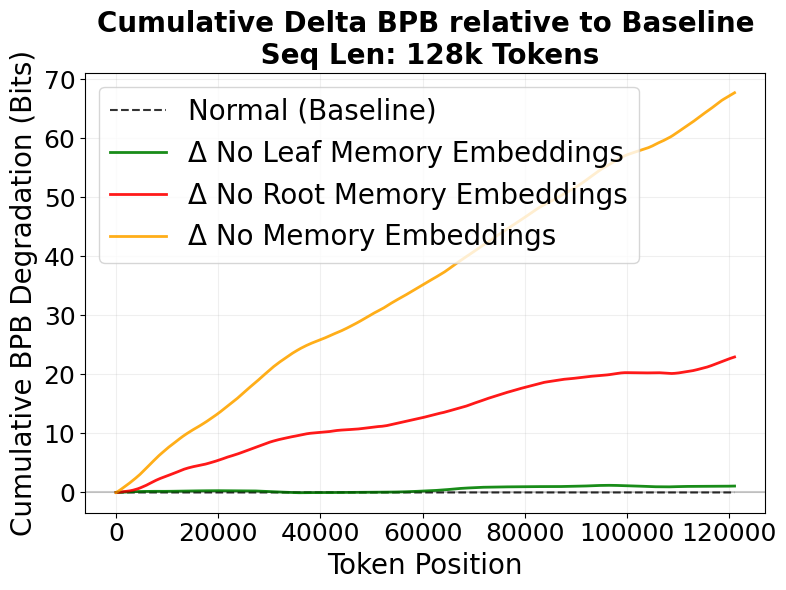

In [1]:
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

CKPT_PATH = "pmnet-icml2026-10724/pmnet"
DATA_PROCESS_BATCH_SIZE = 1000
NUM_PROC = 16
SEQ_LENGTH = 128 * 1024
DATASET_ID = "emozilla/pg19"
DATA_SPLIT = "test"
NUM_EVAL_SAMPLES = 30
loss_save_dir = "data/byte_losses_pg19_128k_hierarchy_test"
os.makedirs(loss_save_dir, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(CKPT_PATH, trust_remote_code=True)
test_dataset = load_dataset(DATASET_ID, split=DATA_SPLIT)
device = "cuda" if torch.cuda.is_available() else "cpu"


def process_batch(examples):
    tokenized = tokenizer(examples["text"])
    input_ids = tokenized["input_ids"]
    input_ids = [ids[:SEQ_LENGTH] for ids in input_ids if len(ids) >= SEQ_LENGTH]
    result = {"input_ids": input_ids}
    return result


test_dataset = test_dataset.map(
    process_batch,
    batched=True,
    batch_size=DATA_PROCESS_BATCH_SIZE,
    remove_columns=test_dataset.column_names,
    num_proc=NUM_PROC,
    desc="Tokenizing",
)

print(f"Number of test samples: {len(test_dataset)}")


def get_loss_over_positions(model, input_ids, chunk_size=1024 * 30):
    model.eval()
    device = model.device
    seq_len = len(input_ids)
    all_losses = []
    past_key_values = None
    criterion = nn.CrossEntropyLoss(reduction="none")

    with torch.no_grad():
        for i in range(0, seq_len, chunk_size):
            end_idx = min(i + chunk_size, seq_len)
            chunk_input = input_ids[i:end_idx]

            label_end_idx = min(i + chunk_size + 1, seq_len)
            chunk_labels_ids = input_ids[i + 1 : label_end_idx]

            input_tensor = (
                torch.tensor(chunk_input, dtype=torch.long).unsqueeze(0).to(device)
            )

            outputs = model(
                input_ids=input_tensor,
                past_key_values=past_key_values,
                use_cache=True,
            )

            past_key_values = outputs.past_key_values
            logits = outputs.logits

            if len(chunk_labels_ids) == len(chunk_input):
                shift_logits = logits.contiguous()
                shift_labels = torch.tensor(chunk_labels_ids, dtype=torch.long).to(
                    device
                )
            else:
                shift_logits = logits[..., :-1, :].contiguous()
                shift_labels = input_tensor[..., 1:].contiguous()

            loss = criterion(
                shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1)
            )
            all_losses.extend(loss.cpu().numpy().tolist())

            del outputs, logits
            torch.cuda.empty_cache()

    return all_losses


def evaluate_hierarchy_ablation():
    print(f"Loading Model from {CKPT_PATH}...")
    model = AutoModelForCausalLM.from_pretrained(
        CKPT_PATH,
        dtype=torch.float32,
        device_map="cuda",
        trust_remote_code=True,
    )
    param_size = sum(p.numel() for p in model.parameters())
    print(f"Model Size: {param_size / 1_000_000_000:.3f}B")

    original_embeddings = [
        emb.clone().detach() for emb in model.model.memory_embeddings
    ]

    modes = [
        ("Normal", "normal", "blue", "Normal (Baseline)"),
        ("Leaf Zero", "leaf_zero", "green", "No Leaf Memory Embeddings"),
        ("Root Zero", "root_zero", "red", "No Root Memory Embeddings"),
        ("All Zero", "all_zero", "orange", "No Memory Embeddings"),
    ]

    dataset = test_dataset.select(range(NUM_EVAL_SAMPLES))
 
    results = {mode_name: [] for mode_name, _, _, _ in modes}

    for i, sample in enumerate(tqdm(dataset, desc="Samples", total=len(dataset))):

        for mode_name, suffix, _, _ in modes:
            save_file = f"{loss_save_dir}/sample_{i}_losses_{suffix}.npy"

            if os.path.exists(save_file):
                losses = np.load(save_file)
                results[mode_name].append(losses)
                continue

            with torch.no_grad():
                for idx, emb in enumerate(model.model.memory_embeddings):
                    emb.data.copy_(original_embeddings[idx])

            with torch.no_grad():
                if mode_name == "Normal":
                    pass  

                elif mode_name == "No Memory Embeddings":
                    for emb in model.model.memory_embeddings:
                        emb.data.fill_(0.0)

                elif mode_name == "No Root Memory Embeddings":
                    model.model.memory_embeddings[0].data.fill_(0.0)

                elif mode_name == "No Leaf Memory Embeddings":
                    model.model.memory_embeddings[-1].data.fill_(0.0)

            losses = get_loss_over_positions(model, sample["input_ids"])
            np.save(save_file, np.array(losses))
            results[mode_name].append(losses)

    plt.figure(figsize=(8, 6))

    def moving_average(a, n=10000):
        ret = np.cumsum(a, dtype=float)
        ret[n:] = ret[n:] - ret[:-n]
        return ret[n - 1 :] / n

    normal_losses = np.array(results["Normal"]).mean(axis=0)
    normal_bpb = moving_average(normal_losses) / 0.693

    for mode_name, suffix, color, label in modes:
        loss_list = results[mode_name]
        if not loss_list:
            continue

        avg_losses = np.array(loss_list).mean(axis=0)
        current_bpb = moving_average(avg_losses) / 0.693

        delta_bpb = current_bpb - normal_bpb

        x_axis = range(len(delta_bpb))
        cumulative_delta = np.cumsum(delta_bpb)
        if mode_name == "Normal":

            plt.plot(
                x_axis,
                cumulative_delta,
                label=label,
                color="black",
                linestyle="--",
                linewidth=1.5,
                alpha=0.8,
            )
        else:
            plt.plot(
                x_axis,
                cumulative_delta,
                label=f"Δ {label}",
                color=color,
                linewidth=2,
                alpha=0.9,
            )

    plt.title(
        f"Cumulative Delta BPB relative to Baseline\n Seq Len: {SEQ_LENGTH//1024}k Tokens",
        fontsize=20,
        fontweight='bold'
    )
    plt.xlabel("Token Position", fontsize=20)
    plt.ylabel("Cumulative BPB Degradation (Bits)", fontsize=20)
    plt.axhline(y=0, color="black", linestyle="-", alpha=0.2)
    plt.legend(loc="upper left", fontsize=20)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)


    save_path = "pmnet_delta_bpb_analysis.pdf"
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Delta graph saved to {save_path}")

    print("\n=== Final Results (Avg BPB) ===")
    for mode_name, _, _, _ in modes:
        if results[mode_name]:
            avg_all_loss = np.mean([np.mean(l) for l in results[mode_name]])
            print(f"{mode_name:10s}: {avg_all_loss / 0.693:.4f} BPB")



evaluate_hierarchy_ablation()